In [57]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [58]:
import torch
from torch import nn, optim
# di sini kita akan masuk ke callback
from jcopdl.callback import Callback, set_config


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Import Data

Karena data kita tanggal jangan lupa di parse date karena jika tidak di parse date bentuknya itu str . 

In [59]:
df = pd.read_csv("data/daily_min_temp.csv", parse_dates=["Date"],index_col="Date")
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


Di sini Akan kita plot

<Axes: xlabel='Date'>

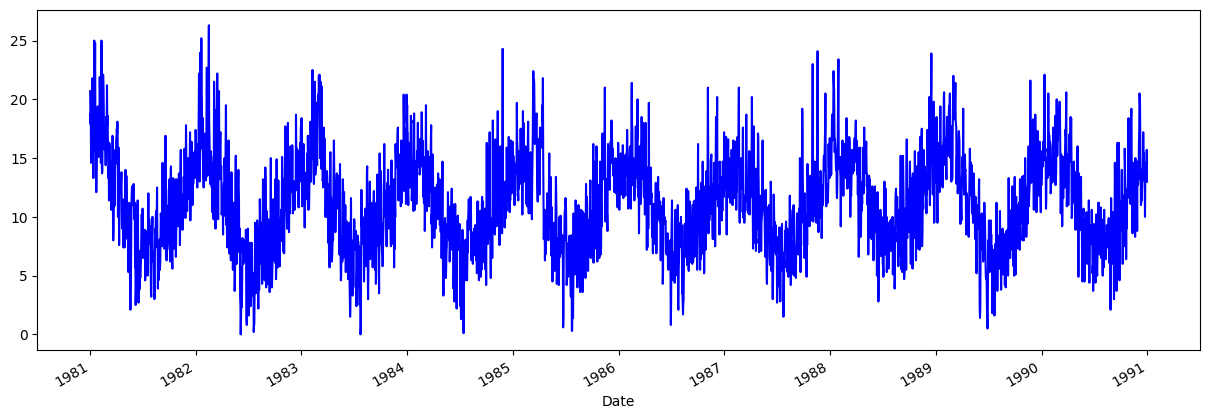

In [60]:
df.Temp.plot(figsize=(15,5), color="b")

1.    Kadang time series itu kita predic nya mingguan aja atau bulanan , jika kita menggunakan time prame yang lebih kecil contoh harian/menit/jam. karena  jika kita menggunakan time prame yang kecil datanya seperti di atas naik turun/noiesy , tetapi kita tetep bisa juga kalau mau pakai time prame kecil. Kita akan pakai data yang time prame nya gedek supaya datanya lebih smoot.

2. Cara unutk datanya supaya smoot kita akan melakukan yang namanya resample nah di bawah ini datanya akan kita resample per week. nah kemudian kita akan kita rata- rata kan perminggunya

In [61]:
df = df.resample("W").mean()

<Axes: xlabel='Date'>

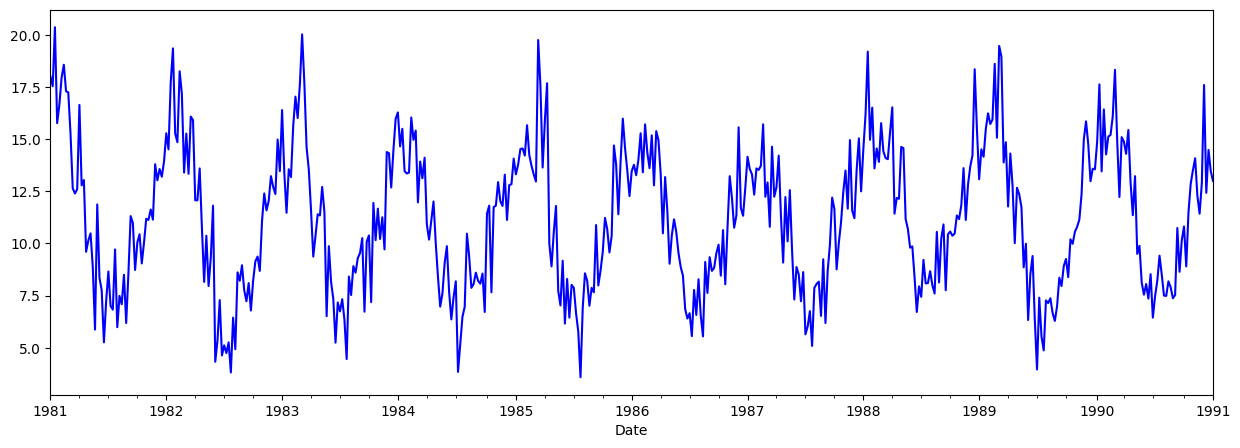

In [62]:
df.Temp.plot(figsize=(15,5), color="b")

In [63]:
df.head()

,Temp
Date,
1981-01-04,18.000000
1981-01-11,17.542857
1981-01-18,20.371429
1981-01-25,15.771429
1981-02-01,16.657143


Nah di sini datanya masih noiesy tapi lebih mending , dan resample itu pilihan terganutng case nya , tapi karena datanya banyak kita akan pakai time prame lebih gedek

# Daset Spliting

1. Ingat jika datanya time serie itu tidak boleh di saffle nanti ngaco

2. Di sini kita tidak ada X dan y karena kolom nya cuman satu yaitu kolom temp

3. yang di split / dibagi itu df kita

4. outputnya itu jadi dua ts_train dan ts_test

In [64]:
ts_train, ts_test = train_test_split(df, test_size=0.2,shuffle=False,)
ts_train.shape, ts_test.shape

((418, 1), (105, 1))

# Daset Dan Dataloder

Kalua datnya multilabel kita pakai multilabeldateset kalau multiclass kita pakai image folder kalau tabular kita pakai Tensor Dataset.

Kalau Time series ? kita akan pakai Library dari jcodl ini adalah costum dataset tapi kalau kita mau manual boleh juga costom datasetnya

In [65]:
from torch.utils.data import  DataLoader
from jcopdl.utils.dataloader import TimeSeriesDataset

1. Yang ini Versi pakai libry jcopdl unutk coustom datasetnya

In [66]:
seq_len = 6
# batch_size nya 16 aja karena datanya dikit
bs = 16

train_set = TimeSeriesDataset(ts_train, "Temp", seq_len)
trainloader = DataLoader(train_set, batch_size=bs, shuffle=True)

test_set = TimeSeriesDataset(ts_test,"Temp", seq_len)
testloader = DataLoader(test_set, batch_size=bs, shuffle=False)

# unutk data yang lebih kita buang aja supya formatnya tetep nsf
# di sini 3 data di buang supaya angkanya tetep bulat

(N, S, F): (69, 6, 1)
Note: last 3 data excluded

(N, S, F): (17, 6, 1)
Note: last 2 data excluded



2. YANG DI BAWAH INI VERSI COSTOM DATASETNYA YANG MANUAL

In [67]:
import torch
from torch.utils.data import Dataset  # Pastikan baris ini ada

class MyTimeSeriesDataset(Dataset):
    def __init__(self, data, target_cols, seq_len):
        self.columns = data.columns.tolist()
        
        # --- Tambahkan ini ---
        # Mengambil indeks dari DataFrame (misal: tanggal/waktu) 
        # mulai dari data ke-seq_len hingga akhir
        self.target_ticks = data.index[seq_len:]
        # ---------------------
        
        if isinstance(target_cols, str):
            target_cols = [target_cols]
            
        for col in target_cols:
            if col not in self.columns:
                raise ValueError(f"Kolom '{col}' tidak ditemukan.")
        
        self.target_indices = [self.columns.index(col) for col in target_cols]
        self.data = torch.tensor(data.values, dtype=torch.float32)
        self.seq_len = seq_len
        self.num_targets = len(target_cols)

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len, self.target_indices]
        return x, y.view(-1) 

    def __repr__(self):
        return f"TimeSeriesDataset(Total Data={len(self.data)}, SeqLen={self.seq_len}, TargetCols={self.num_targets})"

Penjelasan Singkat Logika Utama:
1. __init__: Bertugas sebagai "setup". Kita menyiapkan data agar siap diakses secara cepat oleh model. Mengonversi ke torch.tensor di sini jauh lebih efisien daripada melakukannya berulang kali di dalam __getitem__.

2. __len__: Sangat krusial dalam time-series. Kita tidak bisa menggunakan seluruh panjang data karena saat berada di indeks terakhir, kita tidak punya "masa depan" lagi untuk dijadikan target. Jadi, kita kurangi dengan seq_len.

3. __getitem__: Ini adalah "mesin" utama. Setiap kali DataLoader meminta data (misal: "tolong berikan batch ke-5"), fungsi ini akan memotong data menjadi jendela waktu yang tepat.

In [68]:
seq_len = 6
bs = 32

# unut kolom targetnya lebih dari 1 harus dalam list
# di sini kita kolom targetnya hanya 1 
train_set_2 = MyTimeSeriesDataset(ts_train,"Temp", seq_len)
trainloader_2 = DataLoader(train_set, batch_size=bs, shuffle=True,)

test_set_2 = MyTimeSeriesDataset(ts_test,"Temp",seq_len)
testloader_2 = DataLoader(test_set, batch_size=bs, shuffle=False)

In [69]:
train_set

# Arsitektur dan Config

1. ini Arsitektur dan config pakai libry jcopdl, yang  costom datasetnnya pakai libry jcopdl dan set_confi dari jcopdl

In [70]:
from jcopdl.layers import linear_block

In [71]:
class RNN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        x, hidden = self.rnn(x, hidden)
        x = self.fc(x)
        return x, hidden

In [72]:
config = set_config({
    "input_size": train_set.n_feature,
    "output_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0,
    "seq_len": train_set.n_seq
})

2. ini Arsitektur dan config yang costom dataset buat sendiri dan set_confignya buat sendiri juaga

In [73]:
from jcopdl.layers import linear_block

In [74]:
class RNN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x, hidden):
        x, hidden = self.rnn(x, hidden)
        x = self.fc(x)
        return x, hidden

Di sini kita tidak pakai set_config dari jcopdl tapi kita buat sendiri

In [75]:
from types import SimpleNamespace

def set_config(params):
    return SimpleNamespace(**params)

# Penggunaan:
config = set_config({
    "input_size": train_set_2.data.shape[1], # Mengambil jumlah fitur dari tensor data
    "output_size": train_set_2.num_targets, # Mengambil jumlah target yang sudah diset
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0,
    "seq_len": train_set_2.seq_len  # Mengambil sequence length dari dataset
})

# MCOC

In [76]:
model = RNN(config.input_size, config.output_size,config.hidden_size,config.num_layers, config.dropout).to(device)
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.AdamW(model.parameters(), lr=0.001)
callback = Callback(model, config, outdir="model/rnn")

# Training

In [77]:
from tqdm.auto import tqdm

def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device):
    if mode == "train":
        model.train()
    elif mode == "test":
        model.eval()
    cost = 0
    for feature, target in tqdm(dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        # BEDANYA CUMAN DI SINI DOANG NN DENGAM RNN
        output, hidden = model(feature, None)
        loss = criterion(output, target)
        
        if mode == "train":
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        cost += loss.item() * feature.shape[0]
    cost = cost / len(dataset)
    return cost

Disini kita pakai yang standar

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch     1
Train_cost  = 118.4470 | Test_cost  = 109.5001 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]

...

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    19
Train_cost  = 16.0381 | Test_cost  = 18.4546 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    20
Train_cost  = 15.2444 | Test_cost  = 17.6097 | 


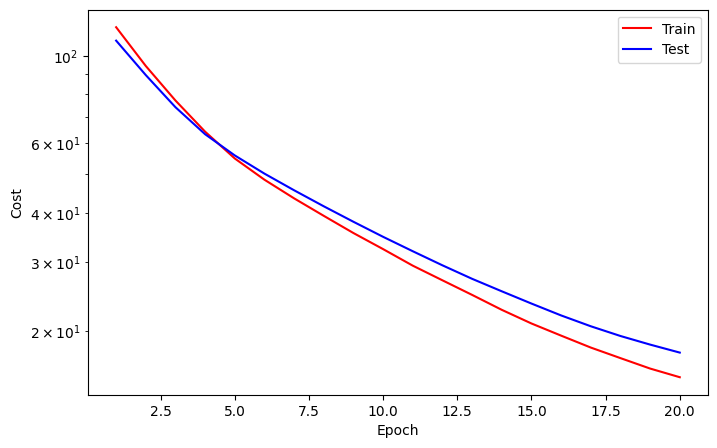

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    21
Train_cost  = 14.5301 | Test_cost  = 16.8511 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]

...

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    39
Train_cost  = 11.0683 | Test_cost  = 12.7552 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    40
Train_cost  = 11.0678 | Test_cost  = 12.7247 | 


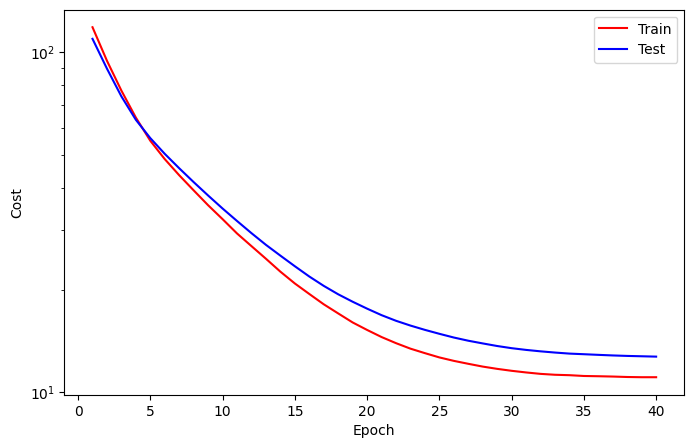

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    41
Train_cost  = 11.0490 | Test_cost  = 12.7081 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]

...

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    59
Train_cost  = 10.9833 | Test_cost  = 12.5870 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    60
Train_cost  = 10.9802 | Test_cost  = 12.5906 | 


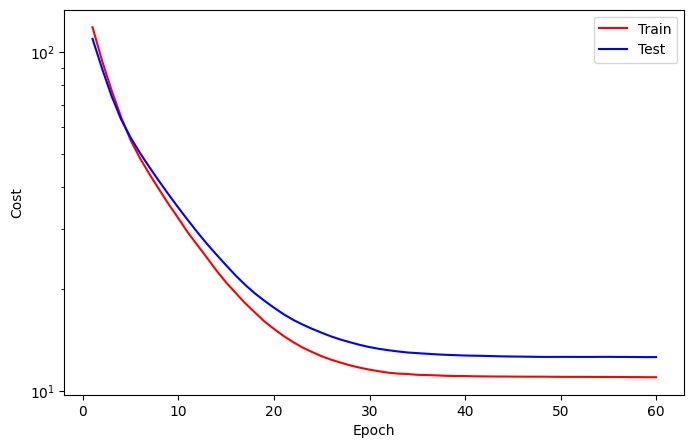

==> EarlyStop patience =  1 | Best test_cost: 12.5870


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    61
Train_cost  = 10.9753 | Test_cost  = 12.5885 | 
==> EarlyStop patience =  2 | Best test_cost: 12.5870


Train:   0%|          | 0/5 [00:00<?, ?it/s]

...

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    79
Train_cost  = 7.4894 | Test_cost  = 8.6780 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    80
Train_cost  = 7.2298 | Test_cost  = 8.3781 | 


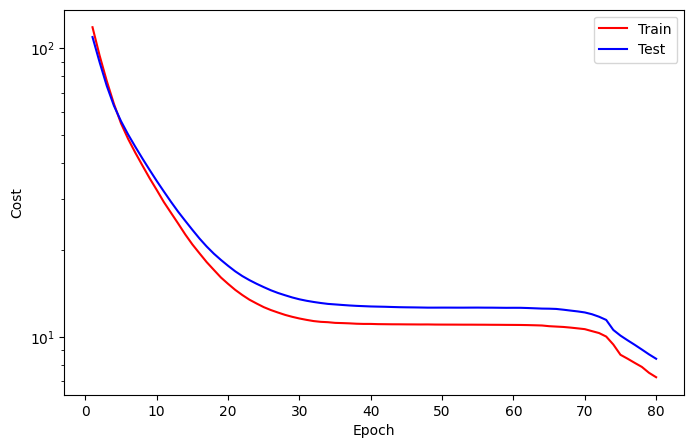

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    81
Train_cost  = 6.9690 | Test_cost  = 8.1411 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]

...

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch    99
Train_cost  = 4.5109 | Test_cost  = 4.8057 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch   100
Train_cost  = 4.4414 | Test_cost  = 4.8467 | 


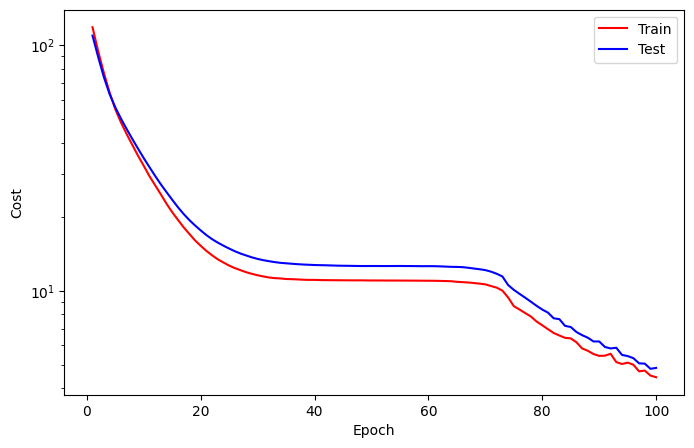

==> EarlyStop patience =  1 | Best test_cost: 4.8057


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch   101
Train_cost  = 4.3809 | Test_cost  = 4.5288 | 


Train:   0%|          | 0/5 [00:00<?, ?it/s]

...

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch   119
Train_cost  = 3.7869 | Test_cost  = 3.6973 | 
==> EarlyStop patience =  2 | Best test_cost: 3.6698


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch   120
Train_cost  = 3.7681 | Test_cost  = 3.6076 | 


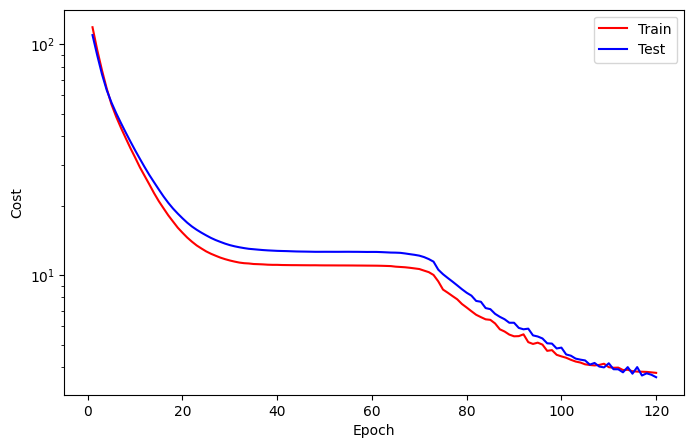

Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch   121
Train_cost  = 3.7580 | Test_cost  = 3.7439 | 
==> EarlyStop patience =  1 | Best test_cost: 3.6076


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]

...


Epoch   130
Train_cost  = 3.6359 | Test_cost  = 3.4531 | 
==> EarlyStop patience =  4 | Best test_cost: 3.3931


Train:   0%|          | 0/5 [00:00<?, ?it/s]

Test:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch   131
Train_cost  = 3.5886 | Test_cost  = 3.4600 | 
==> EarlyStop patience =  5 | Best test_cost: 3.3931
==> Execute Early Stopping at epoch: 131 | Best test_cost: 3.3931
==> Best model is saved at model/rnn


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\jcopdl\callback\_callback.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(

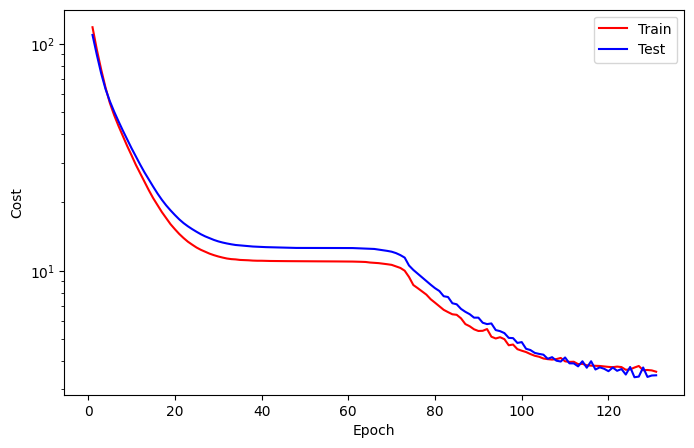

In [78]:
while True:
    train_cost = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)
    
    # Logging
    callback.log(train_cost, test_cost)

    # Checkpoint
    callback.save_checkpoint()
        
    # Runtime Plotting
    callback.cost_runtime_plotting()
    
    # Early Stopping
    if callback.early_stopping(model, monitor="test_cost"):
        callback.plot_cost()
        break

# FORCESTING -> PREDIKSI MASA DEPAN

In [79]:
from luwiji.rnn import illustration

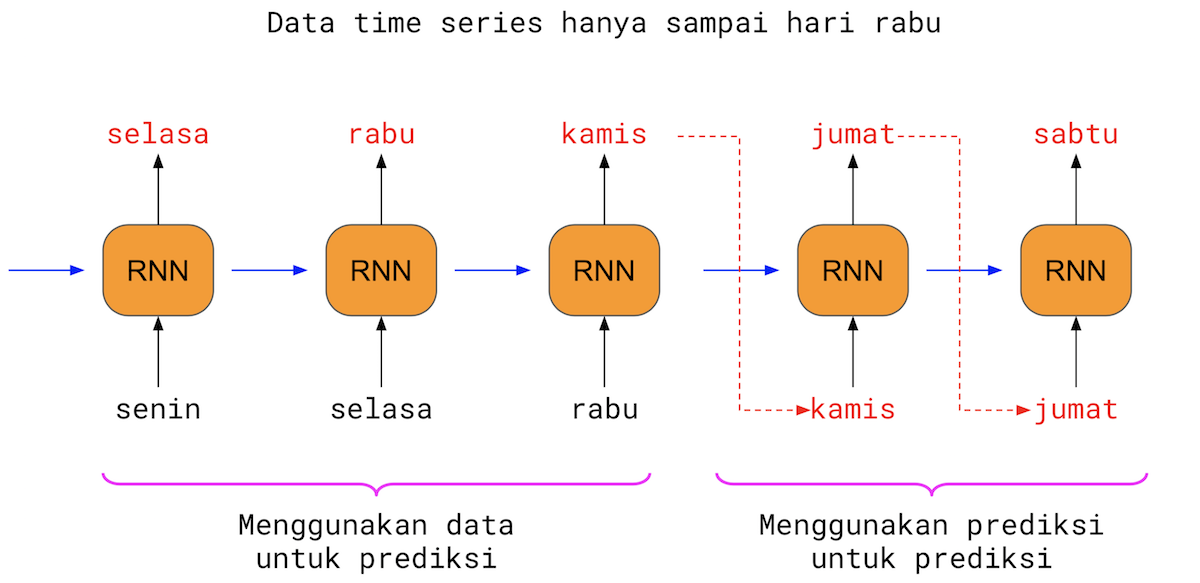

In [80]:
illustration.forecast

1. data4pred yang dipakai pas training dan pred4pred pas test


In [81]:
from utils import data4pred, pred4pred

2. Kemudian dataset dan datalodernya

In [82]:
train_forcest_set_2 = MyTimeSeriesDataset(ts_train,"Temp", 1)
trainforcestloader_2 = DataLoader(train_forcest_set_2)

test_forcest_set_2 = MyTimeSeriesDataset(ts_test,"Temp",1)
testdorcestloader_2 = DataLoader(test_forcest_set_2)

Kenapa seq_len nya kita buang , karena kita tidak akan lagi memikirkan seq_len nya unutk melakukan forcesting kita akan pakai per 1 data maka nya seq_len nya jadi 1. 

jadi input 1 prediksi 1 , input 1 prediksi 1 , biarkayak di illustration.forcest

Text(0.5, 1.0, 'Test')

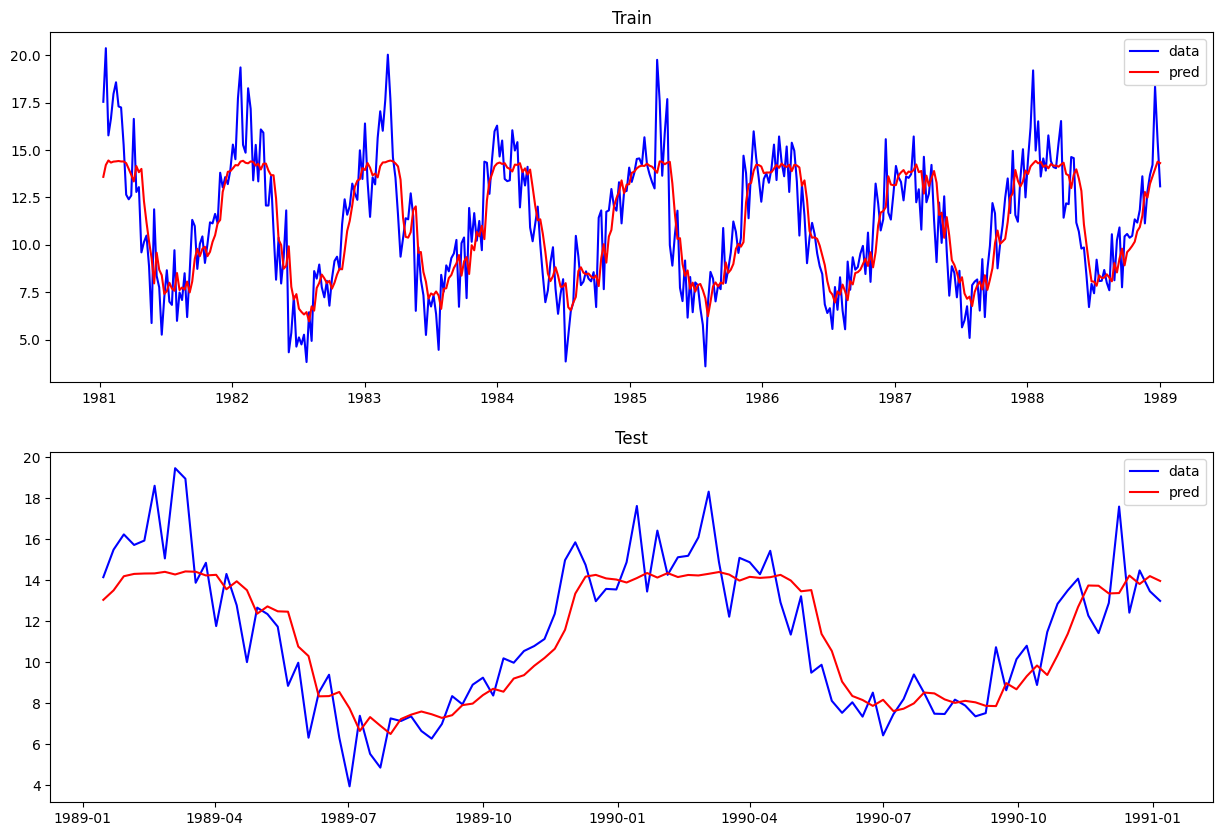

In [83]:
plt.figure(figsize=(15, 10))

plt.subplot(211)
data4pred(model, train_forcest_set_2, trainforcestloader_2, device)
plt.title("Train")

plt.subplot(212)
data4pred(model,test_forcest_set_2, testdorcestloader_2, device)
plt.title("Test")

A. Jadi yang warna biru data asli dan warna merah itu prediksi kita , yang gambar atas data train dan yang gambar bahah itu testnya.

prediksi kita oke kalau ibaratkan prediksi harga saham , harga saham nya bagus . TAPI ini data unutk prediksi jadi kita itu sebenar nya prediski yang di data sudah ada . Jadi fungsi bagian ini itu unutk menghitung loss pada  bagian training makanya hasilnya bagus.




B. coba data sebelah kananya kita hilangkan jadi kita tidak bisa pakai input data lagi ? kita akan pakai prediksi unutk prediksi ? jadi kayak yang di gambar di atas nah pas kita menggunakan cara ini hasilnya tidak akan sebagus pada saat training seperti di atas

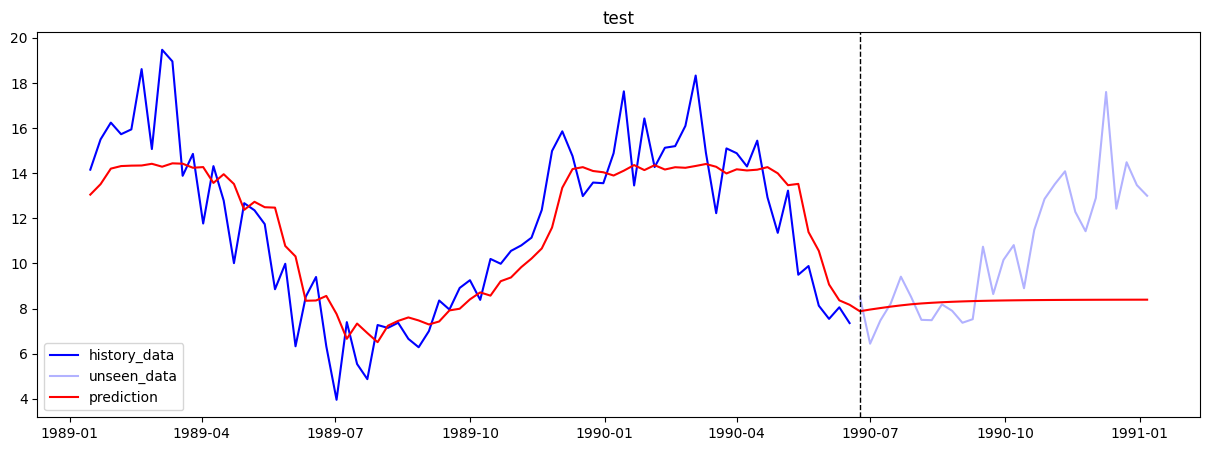

In [84]:
plt.figure(figsize=(15, 5))
pred4pred(model, test_forcest_set_2, testdorcestloader_2 , device)
plt.title("test");

1. Nah pada awal awal pada bagian kanan prediksi kita masih oke minggu 1,2,3  tapi semakin jauh minggu nya 4,5,6,7 dan seterusnya , prediksi kita makin ngaco dibanding data aslinya.

2. Jadi RNN ini jelek ya ? gak gitu juga jadi sebenarnya rnn ini juga bisa bagus , cuman masalhnya semua ini tentang pola , ml itu cuman mesin yang mencari pola .

Nah pertanyaanya ? fitur yang kita masukan itu bermakna tidak ? jadi temperatur kemaren itu katakan 20 derajat tolong prediksi temperatur besok ? emang bermakna apa hubunganya temperatur kemaren terus kita bisa prediksi temperatur besok ?

contoh studi case : 
a.  misalnya compony saya profit 1 t bulan ini, terus saya kasih pertanyaan balik dengan informasi pendafatan 1 t coba prediksi profit compony  saya bulan depan ? :

b. mungkin kita hanya bisa menerka - nerka , kalau bulan lalu 1 t mungkin bulan depan 1 t atau 1,2 t . dua bulan kemudian berapa ? ya 1 t atau 1,2 t. Kenapa karena kita kekurangan informasi . jadi kita tidak tahu kapan naik dan kapan turunya .supaya kita tahu kapan naik dan turunya akan kita lihat grafik data kita 

c. Pas kita lihat grafik data kita kita menemukan patternya nya , istilahnya ada siklus nya.  tiap di akhir tahun temperaturnya cendrung naik dan di awal tahun temperatur cendrung turun dan di pertengahan temperatur nya agak stabil.

d. Jadi naik turun nya ini bukan karena temperatur minggu / bulan lalu . Tapi ternyata ada efek season/musim. karena dg adanya seoseon itu suhu di bumi ini naik turun .

e. apakah fitur temperatur bulan lalu itu masuk akal unutk prediksi unutk prediksi temperatur di bulan besoknya ?. Secara logika ini tidak masuk akal kan kalaau gitu fitur apa yang makesence supya kita mendapatkan informasi yang cukup unutk menentukan temperatur nya berapa 

f. jadi fitur ya itu bulan ini itu bulan apa ? masksudnya bulan ini itu masuk ke musim apa / seson apa , jadi bulannya yang penting bukan temperaturnya. makas sequend_len nya yang tadi 6 akan kita uabh ke 16, karena satu musil itu biasanya 4 bulan . 4 bulan kan itu 16 minggu 

# COBA KITA BUKTIKAN JIKA SEQN_LEN 16 